# Ransomware Detection - Results Visualizations

Simple plots for the results. Run each cell one by one.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

windows = ['25%', '50%', '75%', '100%']

cnn_acc = [95.10, 94.41, 94.41, 95.57]
rf_acc = [93.71, 94.41, 94.17, 94.41]
lstm_acc = [90.44, 89.51, 89.51, 88.34]
transformer_acc = [96.27, 94.41, 95.57, 93.94]

cnn_f1 = [95.10, 94.40, 94.40, 95.57]
rf_f1 = [93.70, 94.40, 94.17, 94.40]
lstm_f1 = [90.44, 89.51, 89.51, 88.33]
transformer_f1 = [96.27, 94.40, 95.57, 93.94]

transformer_precision = [96.30, 94.46, 95.57, 93.95]
transformer_recall = [96.25, 94.37, 95.57, 93.97]

rf_fn = [15, 14, 13, 14]
lstm_fn = [14, 17, 20, 28]
cnn_fn = [10, 13, 11, 11]
transformer_fn = [10, 15, 9, 10]

print("data ready")

data ready


## 1. Transformer accuracy across windows

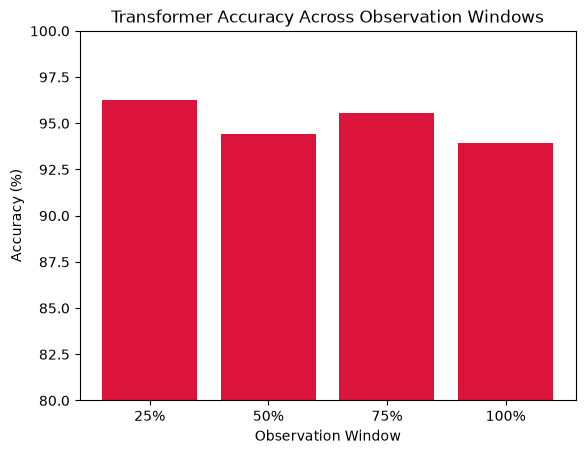

In [2]:
plt.bar(windows, transformer_acc, color='crimson')
plt.xlabel('Observation Window')
plt.ylabel('Accuracy (%)')
plt.title('Transformer Accuracy Across Observation Windows')
plt.ylim(80, 100)
plt.show()

## 2. Accuracy across windows, all four models

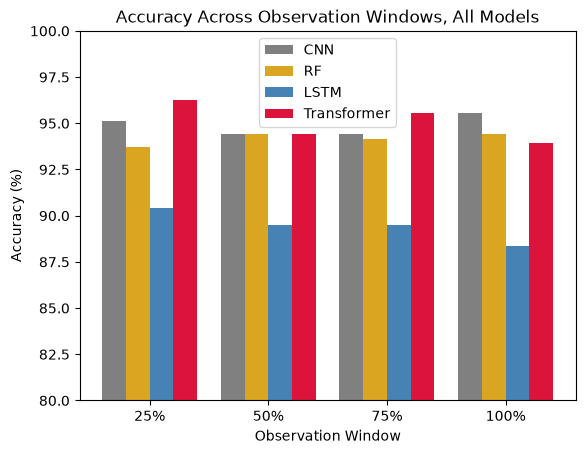

In [3]:
x = np.arange(len(windows))
width = 0.2

plt.bar(x - 1.5*width, cnn_acc, width, label='CNN', color='gray')
plt.bar(x - 0.5*width, rf_acc, width, label='RF', color='goldenrod')
plt.bar(x + 0.5*width, lstm_acc, width, label='LSTM', color='steelblue')
plt.bar(x + 1.5*width, transformer_acc, width, label='Transformer', color='crimson')

plt.xticks(x, windows)
plt.xlabel('Observation Window')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Across Observation Windows, All Models')
plt.ylim(80, 100)
plt.legend()
plt.show()

## 3. F1 score across windows, all four models

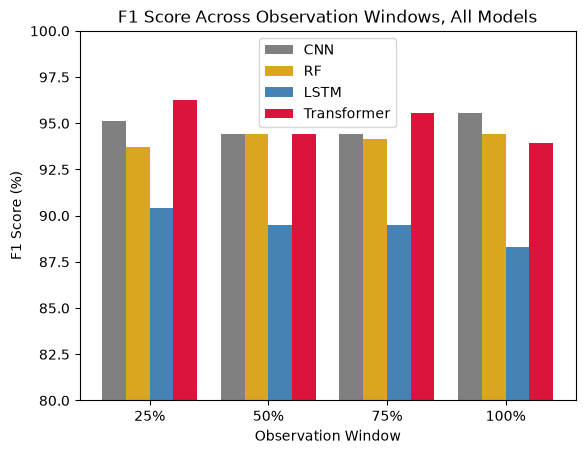

In [4]:
x = np.arange(len(windows))
width = 0.2

plt.bar(x - 1.5*width, cnn_f1, width, label='CNN', color='gray')
plt.bar(x - 0.5*width, rf_f1, width, label='RF', color='goldenrod')
plt.bar(x + 0.5*width, lstm_f1, width, label='LSTM', color='steelblue')
plt.bar(x + 1.5*width, transformer_f1, width, label='Transformer', color='crimson')

plt.xticks(x, windows)
plt.xlabel('Observation Window')
plt.ylabel('F1 Score (%)')
plt.title('F1 Score Across Observation Windows, All Models')
plt.ylim(80, 100)
plt.legend()
plt.show()

## 4. Precision and recall (Transformer)

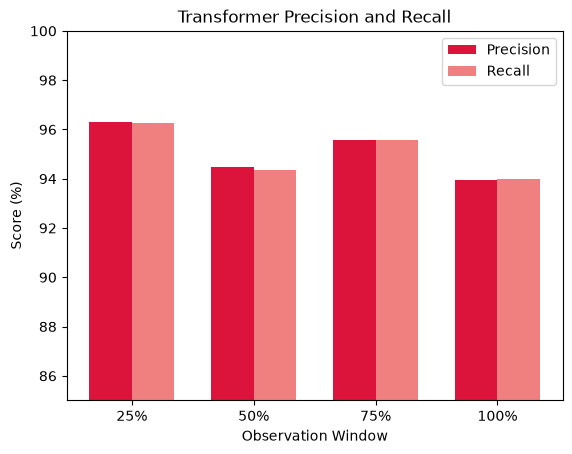

In [5]:
x = np.arange(len(windows))
width = 0.35

plt.bar(x - width/2, transformer_precision, width, label='Precision', color='crimson')
plt.bar(x + width/2, transformer_recall, width, label='Recall', color='lightcoral')

plt.xticks(x, windows)
plt.xlabel('Observation Window')
plt.ylabel('Score (%)')
plt.title('Transformer Precision and Recall')
plt.ylim(85, 100)
plt.legend()
plt.show()

## 5. Accuracy trend line, all four models

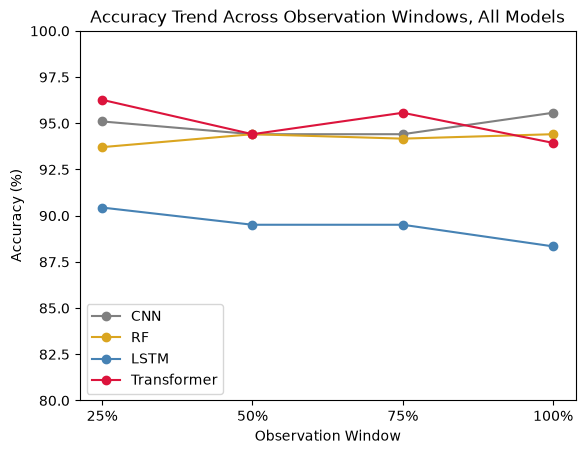

In [6]:
plt.plot(windows, cnn_acc, marker='o', color='gray', label='CNN')
plt.plot(windows, rf_acc, marker='o', color='goldenrod', label='RF')
plt.plot(windows, lstm_acc, marker='o', color='steelblue', label='LSTM')
plt.plot(windows, transformer_acc, marker='o', color='crimson', label='Transformer')

plt.xlabel('Observation Window')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Trend Across Observation Windows, All Models')
plt.ylim(80, 100)
plt.legend()
plt.show()

## 6. Confusion matrices, Transformer, all windows

Format per cell: [[TN, FP], [FN, TP]]. Test set is 429 samples (219 benign, 210 ransomware).

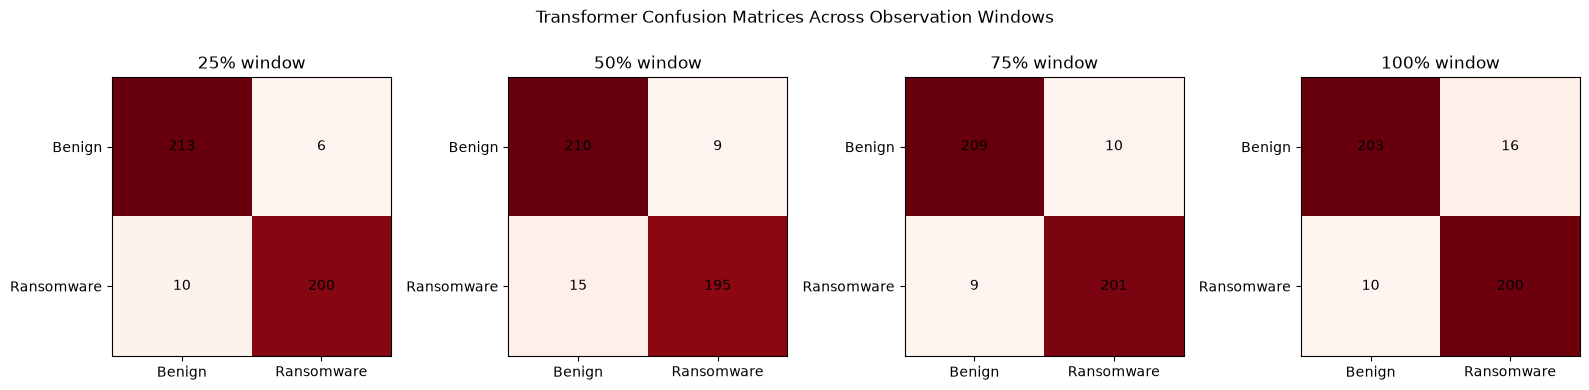

In [7]:
confusion_matrices = {
    'CNN': {
        '25%':  [[208, 11], [10, 200]],
        '50%':  [[208, 11], [13, 197]],
        '75%':  [[206, 13], [11, 199]],
        '100%': [[211, 8],  [11, 199]],
    },
    'RF': {
        '25%':  [[207, 12], [15, 195]],
        '50%':  [[209, 10], [14, 196]],
        '75%':  [[207, 12], [13, 197]],
        '100%': [[209, 10], [14, 196]],
    },
    'LSTM': {
        '25%':  [[192, 27], [14, 196]],
        '50%':  [[191, 28], [17, 193]],
        '75%':  [[194, 25], [20, 190]],
        '100%': [[197, 22], [28, 182]],
    },
    'Transformer': {
        '25%':  [[213, 6],  [10, 200]],
        '50%':  [[210, 9],  [15, 195]],
        '75%':  [[209, 10], [9, 201]],
        '100%': [[203, 16], [10, 200]],
    },
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, w in zip(axes, windows):
    cm = np.array(confusion_matrices['Transformer'][w])
    ax.imshow(cm, cmap='Reds')
    ax.set_title(f'{w} window')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Benign', 'Ransomware'])
    ax.set_yticklabels(['Benign', 'Ransomware'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center')
plt.suptitle('Transformer Confusion Matrices Across Observation Windows')
plt.tight_layout()
plt.show()

## 7. False negatives across windows, all four models

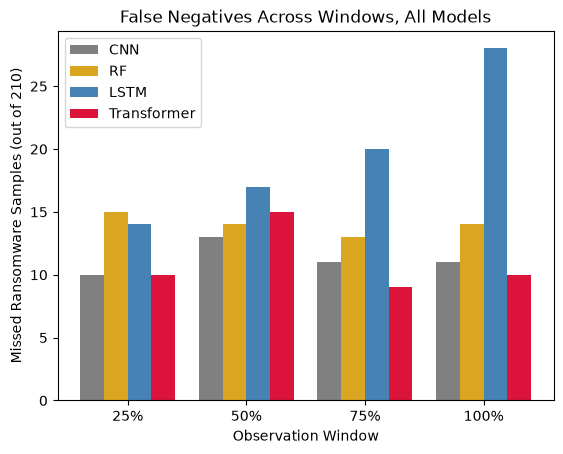

In [8]:
x = np.arange(len(windows))
width = 0.2

plt.bar(x - 1.5*width, cnn_fn, width, label='CNN', color='gray')
plt.bar(x - 0.5*width, rf_fn, width, label='RF', color='goldenrod')
plt.bar(x + 0.5*width, lstm_fn, width, label='LSTM', color='steelblue')
plt.bar(x + 1.5*width, transformer_fn, width, label='Transformer', color='crimson')

plt.xticks(x, windows)
plt.xlabel('Observation Window')
plt.ylabel('Missed Ransomware Samples (out of 210)')
plt.title('False Negatives Across Windows, All Models')
plt.legend()
plt.show()

## 8. Live detection accuracy per family (25% window, Transformer)

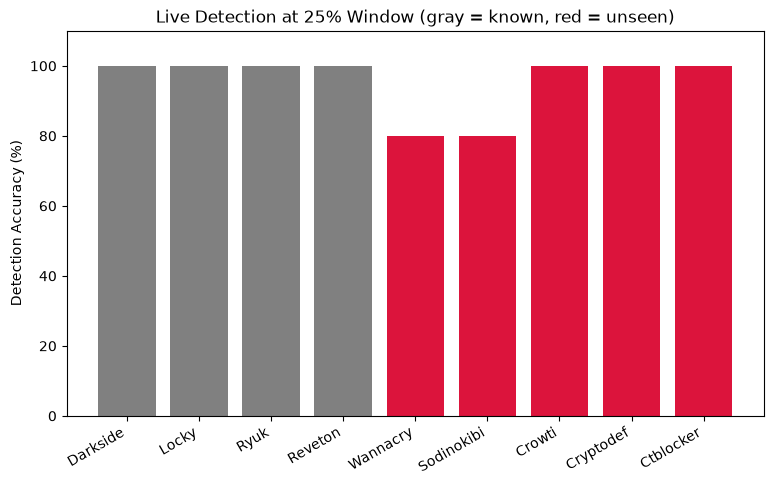

In [9]:
families = ['Darkside', 'Locky', 'Ryuk', 'Reveton', 'Wannacry', 'Sodinokibi', 'Crowti', 'Cryptodef', 'Ctblocker']
accuracy = [100, 100, 100, 100, 80, 80, 100, 100, 100]
is_unseen = [False, False, False, False, True, True, True, True, True]

colors = ['gray' if not unseen else 'crimson' for unseen in is_unseen]

plt.figure(figsize=(9, 5))
plt.bar(families, accuracy, color=colors)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Detection Accuracy (%)')
plt.title('Live Detection at 25% Window (gray = known, red = unseen)')
plt.ylim(0, 110)
plt.show()

## 9. Known vs unseen families across windows (Transformer)

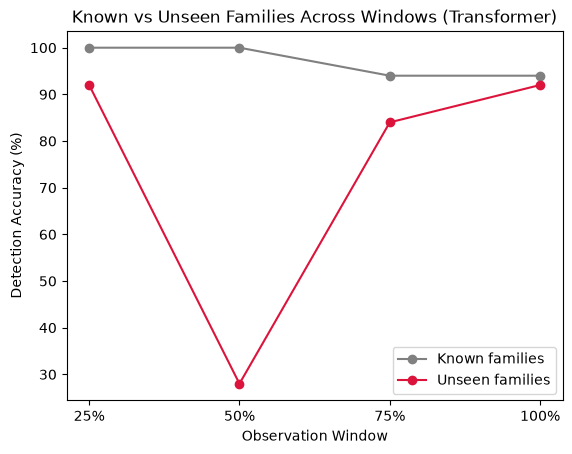

In [10]:
known_acc = [100, 100, 94, 94]
unseen_acc = [92, 28, 84, 92]

plt.plot(windows, known_acc, marker='o', color='gray', label='Known families')
plt.plot(windows, unseen_acc, marker='o', color='crimson', label='Unseen families')

plt.xlabel('Observation Window')
plt.ylabel('Detection Accuracy (%)')
plt.title('Known vs Unseen Families Across Windows (Transformer)')
plt.legend()
plt.show()

## 10. Full results table, all four models

In [11]:
results = pd.DataFrame({
    'Window': windows,
    'CNN Acc': cnn_acc,
    'RF Acc': rf_acc,
    'LSTM Acc': lstm_acc,
    'Transformer Acc': transformer_acc,
    'CNN F1': cnn_f1,
    'RF F1': rf_f1,
    'LSTM F1': lstm_f1,
    'Transformer F1': transformer_f1,
    'CNN FN': cnn_fn,
    'RF FN': rf_fn,
    'LSTM FN': lstm_fn,
    'Transformer FN': transformer_fn,
})

results

,Window,CNN Acc,RF Acc,LSTM Acc,Transformer Acc,CNN F1,RF F1,LSTM F1,Transformer F1,CNN FN,RF FN,LSTM FN,Transformer FN
0,25%,95.10,93.71,90.44,96.27,95.10,93.70,90.44,96.27,10,15,14,10
1,50%,94.41,94.41,89.51,94.41,94.40,94.40,89.51,94.40,13,14,17,15
2,75%,94.41,94.17,89.51,95.57,94.40,94.17,89.51,95.57,11,13,20,9
3,100%,95.57,94.41,88.34,93.94,95.57,94.40,88.33,93.94,11,14,28,10
